Investigate the spatial distribution of solar-energy potential across
Baden-Württemberg and integrate solar-resource information with
administrative geospatial data.

RQ: How does solar irradiation vary spatially across Baden-Württemberg?

Data Source: Using data from PVGIS 

Feature: Using the solar feature "Global Horizontal Irradiation" (GHI) : GHI measures the solar energy received by a horizontal surface from the sky/sun.

In [79]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from matplotlib.patches import Patch

In [36]:
print(rasterio.__version__)

1.4.4


In [3]:
from pathlib import Path

SOLAR_PATH = Path("../data/raw/solar/PVGIS53_annual_irradiation_horizontal_Sarah3_2005_2023.tif")

print(SOLAR_PATH.exists())

True


In [37]:
with rasterio.open(SOLAR_PATH) as src:
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bands:", src.count)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)
    print("Transform:", src.transform)
    print("NoData:", src.nodata)
    print("Data types:", src.dtypes)

Width: 2600
Height: 2450
Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-65.0, bottom=-57.5, right=65.0, top=65.0)
Resolution: (0.05, 0.05)
Transform: | 0.05, 0.00,-65.00|
| 0.00,-0.05, 65.00|
| 0.00, 0.00, 1.00|
NoData: -9999.0
Data types: ('float64',)


In [38]:
with rasterio.open(SOLAR_PATH) as src:
    solar = src.read(1, masked=True)

print("Type:", type(solar))
print("Shape:", solar.shape)

print("Minimum:", solar.min())
print("Maximum:", solar.max())
print("Mean:", solar.mean())
print("Median:", np.ma.median(solar))

Type: <class 'numpy.ma.MaskedArray'>
Shape: (2450, 2600)
Minimum: 486.5575866699219
Maximum: 2586.1123046875
Mean: 1939.4933691702402
Median: 2035.225341796875


In [39]:
print("Masked cells:", solar.mask.sum())
print("Valid cells:", solar.count())

Masked cells: 4302427
Valid cells: 2067573


In [40]:
with rasterio.open(SOLAR_PATH) as src:
    print("Descriptions:", src.descriptions)
    print("Dataset tags:", src.tags())
    print("Band 1 tags:", src.tags(1))
    print("Units:", src.units)

Descriptions: (None,)
Dataset tags: {'AREA_OR_POINT': 'Area'}
Band 1 tags: {}
Units: (None,)


In [41]:
BW_PATH = Path("../data/processed/baden_wuerttemberg.gpkg")

bw_wgs84 = gpd.read_file(
    BW_PATH,
    layer="baden_wuerttemberg"
)

print(bw_wgs84.crs)
print(bw_wgs84.shape)

EPSG:4326
(1, 27)


In [43]:
with rasterio.open(SOLAR_PATH) as src:
    bw_solar, bw_transform = mask(
        src,
        bw_wgs84.geometry,
        crop=True,
        filled=False
    )

In [44]:
print("Original raster shape:", solar.shape)
print("BW raster shape:", bw_solar.shape)

print("Type:", type(bw_solar))
print("Transform:")
print(bw_transform)

Original raster shape: (2450, 2600)
BW raster shape: (1, 46, 60)
Type: <class 'numpy.ma.MaskedArray'>
Transform:
| 0.05, 0.00, 7.50|
| 0.00,-0.05, 49.80|
| 0.00, 0.00, 1.00|


In [45]:
bw_solar_2d = bw_solar[0]

In [50]:
print("Total cells: " ,bw_solar_2d.size)
print("Valid cells:" , bw_solar_2d.count())
print("Masked cells:" , bw_solar_2d.mask.sum())


Total cells:  2760
Valid cells: 1750
Masked cells: 1010


In [51]:
valid_percentage = (bw_solar_2d.count() / bw_solar_2d.size) * 100
print(f"Percentage of valid cells: {valid_percentage:.2f}%")

Percentage of valid cells: 63.41%


In [56]:
print("Average annual horizontal solar irradiation" + "\n" +
      "SARAH3, 2005–2023")
print("Minimum:", bw_solar_2d.min(), "kWh/m²")
print("Maximum:", bw_solar_2d.max(), "kWh/m²")
print("Mean:", bw_solar_2d.mean(), "kWh/m²")
print("Median:", np.ma.median(bw_solar_2d), "kWh/m²")
print("Standard Deviation:", bw_solar_2d.std(), "kWh/m²")

Average annual horizontal solar irradiation
SARAH3, 2005–2023
Minimum: 1026.035400390625 kWh/m²
Maximum: 1282.8909912109375 kWh/m²
Mean: 1204.4952672293527 kWh/m²
Median: 1204.4537963867188 kWh/m²
Standard Deviation: 33.67217556652231 kWh/m²


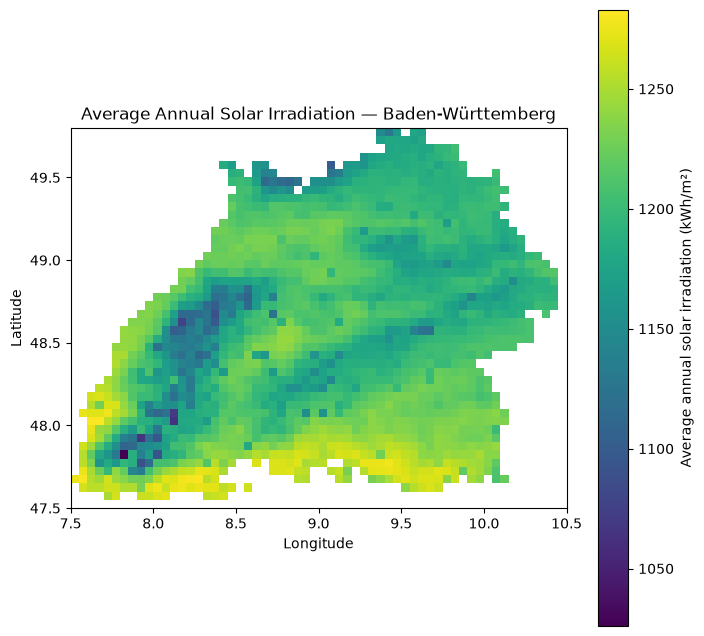

In [64]:
fig, ax = plt.subplots(figsize=(8, 8))

show(
    bw_solar_2d,
    transform=bw_transform,
    ax=ax
)

colorbar = fig.colorbar(
    ax.images[0],
    ax=ax,
    label = "Average annual solar irradiation (kWh/m²)"
)

ax.set_title("Average Annual Solar Irradiation — Baden-Württemberg")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")



plt.show()

In [65]:
solar_values = bw_solar_2d.compressed()

print(type(solar_values))
print(solar_values.shape)

<class 'numpy.ndarray'>
(1750,)


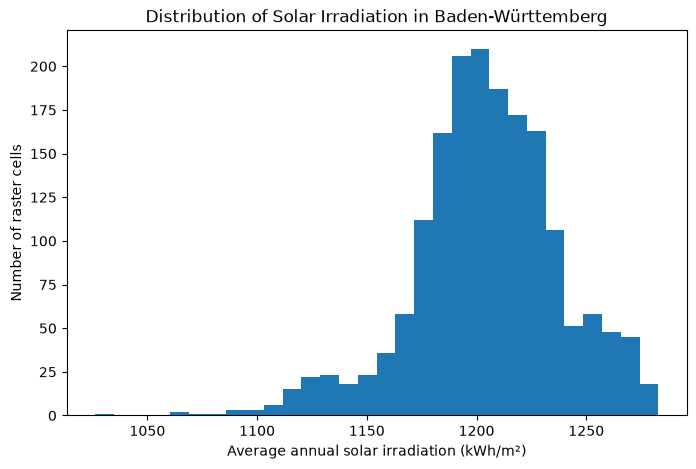

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    solar_values,
    bins=30
)

ax.set_xlabel("Average annual solar irradiation (kWh/m²)")
ax.set_ylabel("Number of raster cells")
ax.set_title("Distribution of Solar Irradiation in Baden-Württemberg")

plt.show()

In [67]:
np.percentile(solar_values, [10, 25, 50, 75, 90])

array([1166.92285156, 1186.73944092, 1204.45379639, 1225.66220093,
       1247.89066162])

We want to consider the area which has high solar resource relative to the rest of BW

In [68]:
solar_p90 = np.percentile(solar_values, 90)

In [69]:
high_solar = bw_solar_2d >= solar_p90

In [71]:
print(type(high_solar))
print(high_solar.shape)

<class 'numpy.ma.MaskedArray'>
(46, 60)


In [72]:
print("90th percentile:", solar_p90)
print("High-solar cells:", high_solar.sum())

90th percentile: 1247.8906616210938
High-solar cells: 175


We only consider the cells which are in the top 10% - containing values higher than the 90th percentile value

In [73]:
valid_cells = bw_solar_2d.count()

print("Valid BW cells:", valid_cells)
print("Expected ~10%:", valid_cells * 0.10)
print("High-solar cells:", high_solar.sum())
print(
    "Actual percentage:",
    high_solar.sum() / valid_cells * 100
)

Valid BW cells: 1750
Expected ~10%: 175.0
High-solar cells: 175
Actual percentage: 10.0


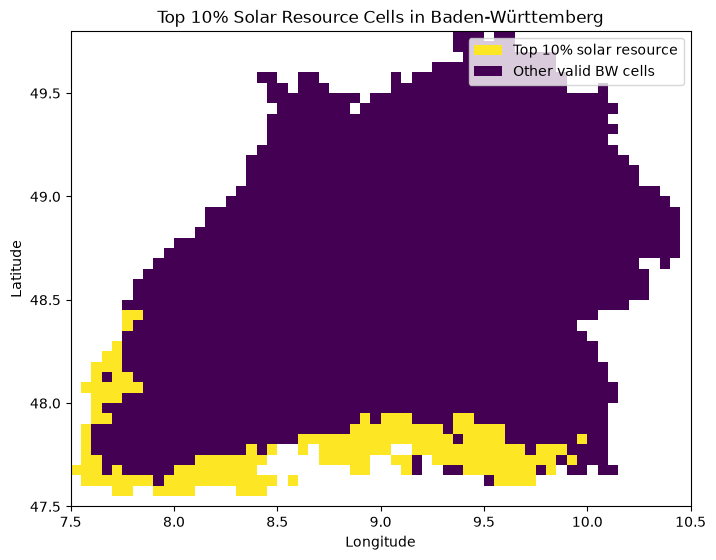

In [80]:
fig, ax = plt.subplots(figsize=(8, 8))

show(
    high_solar,
    transform=bw_transform,
    ax=ax
)

image = ax.images[0]
cmap = image.get_cmap()

legend_elements = [
    Patch(
        facecolor=cmap(1.0),
        label="Top 10% solar resource"
    ),
    Patch(
        facecolor=cmap(0.0),
        label="Other valid BW cells"
    )
]



ax.set_title("Top 10% Solar Resource Cells in Baden-Württemberg")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(handles=legend_elements)

plt.show()

In [75]:
print(type(high_solar))
print("Is masked array:", np.ma.isMaskedArray(high_solar))
print("Masked cells:", high_solar.mask.sum())

<class 'numpy.ma.MaskedArray'>
Is masked array: True
Masked cells: 1010
